# Assignment 1 | EDA 1: Raw data exploration
Exploratory Data Analysis of 4 raw data files for loan default prediction.

**Structure:**
1. Data Shapes: shape, columns, dtypes, customer counts
2. Data Quality Audit Overview: nulls, dirty values (manual observation), customer overlap, date structrure
3. Descriptive Statistics: summary stats, outlier detection, binning recommendations
4. Target Variable: derived from loan table

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import re
pd.set_option('display.max_columns', None)

---
## 1. Data Overview

In [3]:
df_loan = pd.read_csv('data/lms_loan_daily.csv')
df_click = pd.read_csv('data/feature_clickstream.csv')
df_attr = pd.read_csv('data/features_attributes.csv')
df_fin = pd.read_csv('data/features_financials.csv')

for name, df in [('loan', df_loan), ('clickstream', df_click), ('attributes', df_attr), ('financials', df_fin)]:
    print(f'--- {name} ---')
    print(f'Shape: {df.shape}')
    print(f'Columns: {list(df.columns)}')
    print(f'Unique customers: {df["Customer_ID"].nunique()}')
    print()

--- loan ---
Shape: (137500, 11)
Columns: ['loan_id', 'Customer_ID', 'loan_start_date', 'tenure', 'installment_num', 'loan_amt', 'due_amt', 'paid_amt', 'overdue_amt', 'balance', 'snapshot_date']
Unique customers: 12500

--- clickstream ---
Shape: (215376, 22)
Columns: ['fe_1', 'fe_2', 'fe_3', 'fe_4', 'fe_5', 'fe_6', 'fe_7', 'fe_8', 'fe_9', 'fe_10', 'fe_11', 'fe_12', 'fe_13', 'fe_14', 'fe_15', 'fe_16', 'fe_17', 'fe_18', 'fe_19', 'fe_20', 'Customer_ID', 'snapshot_date']
Unique customers: 8974

--- attributes ---
Shape: (12500, 6)
Columns: ['Customer_ID', 'Name', 'Age', 'SSN', 'Occupation', 'snapshot_date']
Unique customers: 12500

--- financials ---
Shape: (12500, 22)
Columns: ['Customer_ID', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_His

In [4]:
df_loan.head()

,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,0,10000,0.0,0.0,0.0,10000.0,2023-05-01
1,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,1,10000,1000.0,1000.0,0.0,9000.0,2023-06-01
2,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2023-07-01
3,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,3,10000,1000.0,0.0,1000.0,8000.0,2023-08-01
4,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,4,10000,1000.0,2000.0,0.0,6000.0,2023-09-01


On loan table, each customer has one loan_id. Each loan_id has one loan_start_date and many snapshot_date.

In [5]:
df_click.head()

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,63,118,80,121,55,193,111,112,-101,83,164,105,-16,-81,-126,114,35,85,-73,76,CUS_0x1037,2023-01-01
1,-108,182,123,4,-56,27,25,-6,284,222,203,190,-14,-96,200,35,130,94,111,75,CUS_0x1069,2023-01-01
2,-13,8,87,166,214,-98,215,152,129,139,14,203,26,86,171,125,-130,354,17,302,CUS_0x114a,2023-01-01
3,-85,45,200,89,128,54,76,51,61,139,6,197,172,96,174,163,37,207,180,118,CUS_0x1184,2023-01-01
4,55,120,226,-86,253,97,107,68,103,126,34,12,76,43,183,159,-26,104,118,184,CUS_0x1297,2023-01-01


In [6]:
df_attr.head()

,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x1000,Alistair Barrf,18,913-74-1218,Lawyer,2023-05-01
1,CUS_0x1009,Arunah,26,063-67-6938,Mechanic,2025-01-01
2,CUS_0x100b,Shirboni,19,#F%$D@*&8,Media_Manager,2024-03-01
3,CUS_0x1011,Schneyerh,44,793-05-8223,Doctor,2023-11-01
4,CUS_0x1013,Cameront,44,930-49-9615,Mechanic,2023-12-01


In [7]:
df_fin.head()

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x1000,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, and Home Equity Loan",57,26,1.63,11.0,Bad,1562.91,30.077191,10 Years and 9 Months,Yes,42.941090,77.31427572208112,High_spent_Medium_value_payments,400.36080052211616,2023-05-01
1,CUS_0x1009,52312.68_,4250.390000,6,5,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",5,18,9.73,4.0,_,202.68,40.286997,31 Years and 0 Months,Yes,108.366467,58.66019164829086,High_spent_Medium_value_payments,508.01234122645366,2025-01-01
2,CUS_0x100b,113781.38999999998,9549.782500,1,4,1,0,NaN,14,8,8.34,4.0,Good,1030.2,28.592943,15 Years and 10 Months,No,0.000000,617.0792665202719,High_spent_Small_value_payments,597.8989834797281,2024-03-01
3,CUS_0x1011,58918.47,5208.872500,3,3,17,3,"Student Loan, Credit-Builder Loan, and Debt Co...",27,13,14.42,7.0,Standard,473.14,27.829959,15 Years and 10 Months,Yes,123.434939,383.35084463651407,Low_spent_Medium_value_payments,294.1014665671429,2023-11-01
4,CUS_0x1013,98620.98,7962.415000,3,3,6,3,"Student Loan, Debt Consolidation Loan, and Per...",12,9,1.33,3.0,Good,1233.51,26.524864,17 Years and 10 Months,No,228.018084,332.3337079767732,High_spent_Medium_value_payments,485.8897083704929,2023-12-01


---
## 2. Data Quality Audit

### 2.1 Customer Overlap

In [8]:
loan_custs = set(df_loan['Customer_ID'].unique())
click_custs = set(df_click['Customer_ID'].unique())
attr_custs = set(df_attr['Customer_ID'].unique())
fin_custs = set(df_fin['Customer_ID'].unique())

print('Customer counts per file:')
print(f'  Loan:        {len(loan_custs)}')
print(f'  Clickstream: {len(click_custs)}')
print(f'  Attributes:  {len(attr_custs)}')
print(f'  Financials:  {len(fin_custs)}')
print()
print('Overlap with Loan:')
print(f'  Clickstream & Loan: {len(click_custs & loan_custs)}')
print(f'  Attributes & Loan:  {len(attr_custs & loan_custs)}')
print(f'  Financials & Loan:  {len(fin_custs & loan_custs)}')
print(f'  All 4 files:        {len(click_custs & attr_custs & fin_custs & loan_custs)}')
print()
print('Customers in Loan but NOT in Clickstream:', len(loan_custs - click_custs))

Customer counts per file:
  Loan:        12500
  Clickstream: 8974
  Attributes:  12500
  Financials:  12500

Overlap with Loan:
  Clickstream & Loan: 8974
  Attributes & Loan:  12500
  Financials & Loan:  12500
  All 4 files:        8974

Customers in Loan but NOT in Clickstream: 3526


### 2.2 Snapshot Date Structure

In [9]:
# Clickstream: multiple rows per customer
print('Clickstream rows per customer:', df_click.groupby('Customer_ID').size().unique())

# Attributes & financials: 1 row per customer, snapshot_date = loan_start_date
loan_starts = df_loan[['Customer_ID', 'loan_start_date']].drop_duplicates()
merged = loan_starts.merge(df_attr[['Customer_ID', 'snapshot_date']], on='Customer_ID')
print('Attributes snapshot_date == loan_start_date:', (merged['snapshot_date'] == merged['loan_start_date']).all())

merged2 = loan_starts.merge(df_fin[['Customer_ID', 'snapshot_date']], on='Customer_ID')
print('Financials snapshot_date == loan_start_date:', (merged2['snapshot_date'] == merged2['loan_start_date']).all())

Clickstream rows per customer: [24]
Attributes snapshot_date == loan_start_date: True
Financials snapshot_date == loan_start_date: True


- So on click table, each customer has 24 events (rows). <br>
- The loan_start_date array matches the snapshot_date arrays from attr and fin tables.

### 2.3 Dtypes and Nulls per Table

In [10]:
for name, df in [('Loan', df_loan), ('Clickstream', df_click), ('Attributes', df_attr), ('Financials', df_fin)]:
    print(f'=== {name} ===')
    print(f'Dtypes:\n{df.dtypes}\n')
    null_count = df.isnull().sum()
    if null_count.sum() > 0:
        print(f'Null counts:\n{null_count[null_count > 0]}\n')
    else:
        print('Nulls: 0\n')
    print()

=== Loan ===
Dtypes:
loan_id             object
Customer_ID         object
loan_start_date     object
tenure               int64
installment_num      int64
loan_amt             int64
due_amt            float64
paid_amt           float64
overdue_amt        float64
balance            float64
snapshot_date       object
dtype: object

Nulls: 0


=== Clickstream ===
Dtypes:
fe_1              int64
fe_2              int64
fe_3              int64
fe_4              int64
fe_5              int64
fe_6              int64
fe_7              int64
fe_8              int64
fe_9              int64
fe_10             int64
fe_11             int64
fe_12             int64
fe_13             int64
fe_14             int64
fe_15             int64
fe_16             int64
fe_17             int64
fe_18             int64
fe_19             int64
fe_20             int64
Customer_ID      object
snapshot_date    object
dtype: object

Nulls: 0


=== Attributes ===
Dtypes:
Customer_ID      object
Name             object

- Loan table, attribute table: no null values. <br>
- Click table: all numeric, no nulls -> no cleaning needed. Do not know the meaning of these features. <br>
- Financials table: 1426 rows null.

### 2.4 Dirty Values - Attributes Table

In [11]:
# Name, SSN: should be removed (PII). SSN also has garbage format (e.g., '#F%$D@*&8')
print('Name sample:', df_attr['Name'].head(3).tolist())
print('SSN sample:', df_attr['SSN'].head(3).tolist())
print()

# Age: trailing underscores, negatives, unreasonable values
age_cleaned = pd.to_numeric(df_attr['Age'].astype(str).str.rstrip('_'), errors='coerce')
print('Age range after stripping "_":', age_cleaned.min(), 'to', age_cleaned.max())
print('Negative ages:', (age_cleaned < 0).sum())
print('Ages > 100:', (age_cleaned > 100).sum())
print()

# Occupation: placeholder values
print('Occupation values:')
print(df_attr['Occupation'].value_counts())
print('Placeholder rows:', df_attr['Occupation'].str.contains('__', na=False).sum())

Name sample: ['Alistair Barrf', 'Arunah', 'Shirboni']
SSN sample: ['913-74-1218', '063-67-6938', '#F%$D@*&8']

Age range after stripping "_": -500 to 8678
Negative ages: 104
Ages > 100: 215

Occupation values:
Occupation
_______          880
Lawyer           828
Architect        795
Engineer         793
Accountant       791
Scientist        789
Teacher          782
Media_Manager    780
Mechanic         780
Developer        780
Entrepreneur     776
Journalist       761
Doctor           760
Musician         741
Manager          736
Writer           728
Name: count, dtype: int64
Placeholder rows: 880


Note for data cleaning in attribute table:
- Name, SNN: format issue but should remove, due to privacy concerns. <br>
- Age: trailing underscores, negative, too big number. <br>
- Occupation: placeholder.

### 2.5 Dirty Values - Financials Table

In [12]:
# Numeric columns with trailing underscores or non-numeric entries
dirty_cols = ['Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
              'Changed_Credit_Limit', 'Outstanding_Debt',
              'Amount_invested_monthly', 'Monthly_Balance']

for c in dirty_cols:
    bad = df_fin[pd.to_numeric(df_fin[c], errors='coerce').isna()]
    print(f'{c}: {len(bad)} non-numeric rows', end='')
    if len(bad) > 0:
        print(f'  e.g. {bad[c].head(3).tolist()}')
    else:
        print()

Annual_Income: 859 non-numeric rows  e.g. ['52312.68_', '49718.55_', '20652.98_']
Num_of_Loan: 623 non-numeric rows  e.g. ['1_', '6_', '2_']
Num_of_Delayed_Payment: 374 non-numeric rows  e.g. ['18_', '20_', '0_']
Changed_Credit_Limit: 254 non-numeric rows  e.g. ['_', '_', '_']
Outstanding_Debt: 139 non-numeric rows  e.g. ['2699.17_', '642.42_', '755.17_']
Amount_invested_monthly: 558 non-numeric rows  e.g. ['__10000__', '__10000__', '__10000__']
Monthly_Balance: 1 non-numeric rows  e.g. ['__-333333333333333333333333333__']


Note for data cleaning in financial table:
- Annual_Income: trailing underscores. Number differentiation gap is big but hard to cut off (do not know currency and income has sensitive limit).<br>
- Monthly_Inhand_Salary: all float but abnormal number (too big, eg: 9982 months ~ >800 years) <br>
- Num_Bank_Accounts, Num_Credit_Card, Interest_Rate: all int but abnormal number (negative, too big) <br>
- Num_of_Loan: trailing underscore, negative number. Some numbers are too big (eg: CUS_0x1274, 4041 loans for student and payday loans). I do not know the rule to cut off but it's better to double check with original sources/relevant parties. <br>
- Type_of_Loan: null rows, duplicated values, can pivot values but maybe no need to use. <br>
- Num_of_Delayed_Payment: remove negative number, trailing underscore <br>
- Changed_Credit_Limit: number absolute gap is not too wide but have negative numbers. Should google/confirm with relevant parties about it.
- Credit_Mix: encode, remove (_) <br>
- Outstanding_Debt: trailing underscores. <br>
- Credit_History_Age: encode to use. <br>
- Payment_of_Min_Amount: Yes, No, NM. Do not know what NM means, can encode if used.<br>
- Total_EMI_per_month: big number (eg: 993) -> need to gg/check with relevant parties about limitation, check distribution  <br>
- Amount_invested_monthly: trailing underscores
- Payment_Behaviour: encode, remove out of list value.<br>
- Monthly_Balance: trailing scores.

### 2.6 Loan Table Quick Check

In [13]:
# Sample customer with multiple overdue installments
overdue_counts = df_loan[df_loan['overdue_amt'] > 0].groupby('Customer_ID').size()
sample_customer = overdue_counts[overdue_counts > 2].index[0]
df_loan[df_loan['Customer_ID'] == sample_customer].sort_values('snapshot_date')

,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,0,10000,0.0,0.0,0.0,10000.0,2023-05-01
1,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,1,10000,1000.0,1000.0,0.0,9000.0,2023-06-01
2,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2023-07-01
3,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,3,10000,1000.0,0.0,1000.0,8000.0,2023-08-01
4,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,4,10000,1000.0,2000.0,0.0,6000.0,2023-09-01
5,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,5,10000,1000.0,0.0,1000.0,6000.0,2023-10-01
6,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,6,10000,1000.0,0.0,2000.0,6000.0,2023-11-01
7,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,7,10000,1000.0,0.0,3000.0,6000.0,2023-12-01
8,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,8,10000,1000.0,0.0,4000.0,6000.0,2024-01-01
9,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,9,10000,1000.0,0.0,5000.0,6000.0,2024-02-01


Note for loan table:
- Data itself seems okay and simple.
- Tenure is always 10 months, loan amount: 10000, due amount: 1000 or 0.
- All numbers are in allowance range.
- Loan_start_date: from 1 Jan 2023- 1 Jan 2025. Snapshot_date: 1 Jan 2023- 1 Nov 2025 => sensible for 10-month tenure (eg: CUS_0x1009).

---
## 3. Descriptive Statistics
Summary statistics with extended percentiles (1%, 5%, 25%, 50%, 75%, 95%, 99%) to catch outliers at the tails. IQR-based outlier detection for the financials table. Categorical columns get value counts.

### 3.1 Loan Table

In [14]:
df_loan.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance
count,137500.0,137500.000000,137500.0,137500.000000,137500.000000,137500.000000,137500.000000
mean,10.0,5.000000,10000.0,909.090909,711.810909,871.905455,5871.905455
std,0.0,3.162289,0.0,287.480833,485.726859,2002.672544,3070.777575
min,10.0,0.000000,10000.0,0.000000,0.000000,0.000000,0.000000
1%,10.0,0.000000,10000.0,0.000000,0.000000,0.000000,0.000000
5%,10.0,0.000000,10000.0,0.000000,0.000000,0.000000,0.000000
25%,10.0,2.000000,10000.0,1000.000000,0.000000,0.000000,3000.000000
50%,10.0,5.000000,10000.0,1000.000000,1000.000000,0.000000,7000.000000
75%,10.0,8.000000,10000.0,1000.000000,1000.000000,0.000000,8000.000000
95%,10.0,10.000000,10000.0,1000.000000,1000.000000,6000.000000,10000.000000


**Observations - Loan table:**
- tenure (always 10), loan_amt (always 10,000), due_amt (0 or 1,000) have zero variance. Not useful as features.
- paid_amt: ranges 0 to 4,000. Max of 4,000 means some customers pay multiple overdue installments at once.
- overdue_amt: 75th percentile is 0, meaning most installments are paid on time. At 95th percentile it jumps to 6,000, showing chronic non-payers.
- balance: no negatives, max is 10,000. No outliers in the traditional sense.
- **No cleaning needed. No binning needed.** This table is primarily for deriving the target variable (default label).

### 3.2 Clickstream Table

In [15]:
fe_cols = [c for c in df_click.columns if c.startswith('fe_')]
df_click[fe_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
count,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000
mean,101.414796,103.096195,104.333709,105.648503,106.996676,103.235922,107.070337,110.718724,114.406354,117.775797,99.615537,99.823680,100.420804,100.025801,99.600383,99.860834,100.129425,100.125139,100.341162,100.046259
std,99.833594,99.930002,100.599865,100.326065,100.693607,100.270388,100.323265,100.243698,100.186139,100.807686,100.335428,100.591175,100.881826,101.070371,101.145906,100.751876,101.298428,102.231587,102.666804,103.589358
min,-378.000000,-356.000000,-399.000000,-307.000000,-343.000000,-321.000000,-368.000000,-361.000000,-328.000000,-317.000000,-375.000000,-344.000000,-355.000000,-394.000000,-351.000000,-342.000000,-329.000000,-344.000000,-401.000000,-354.000000
1%,-130.000000,-129.000000,-130.000000,-128.000000,-129.000000,-129.000000,-126.000000,-122.000000,-118.250000,-117.000000,-134.000000,-135.000000,-134.250000,-135.000000,-136.000000,-135.000000,-136.000000,-138.000000,-138.000000,-142.000000
5%,-62.000000,-61.000000,-61.000000,-60.000000,-59.000000,-62.000000,-58.000000,-54.000000,-51.000000,-48.000000,-65.000000,-66.000000,-66.000000,-66.000000,-67.000000,-67.000000,-66.000000,-68.000000,-68.000000,-70.000000
25%,34.000000,36.000000,36.000000,38.000000,39.000000,36.000000,39.000000,43.000000,47.000000,50.000000,32.000000,32.000000,33.000000,32.000000,31.000000,32.000000,32.000000,31.000000,31.000000,30.000000
50%,102.000000,103.000000,104.000000,106.000000,107.000000,103.000000,107.000000,111.000000,115.000000,118.000000,100.000000,100.000000,101.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
75%,169.000000,171.000000,172.000000,173.000000,175.000000,171.000000,174.000000,179.000000,182.000000,186.000000,167.000000,168.000000,168.000000,168.000000,168.000000,168.000000,169.000000,169.000000,170.000000,170.000000
95%,266.000000,268.000000,269.000000,270.000000,272.000000,268.000000,272.000000,276.000000,279.000000,284.000000,265.000000,265.000000,266.000000,267.000000,266.000000,265.000000,267.000000,268.000000,270.000000,270.000000


In [16]:
# Check skewness across all clickstream features
print('Skewness of clickstream features:')
print(df_click[fe_cols].skew().round(4))

Skewness of clickstream features:
fe_1     0.0101
fe_2    -0.0032
fe_3     0.0009
fe_4    -0.0028
fe_5    -0.0062
fe_6     0.0056
fe_7     0.0011
fe_8     0.0015
fe_9    -0.0021
fe_10    0.0024
fe_11    0.0045
fe_12   -0.0053
fe_13   -0.0060
fe_14    0.0036
fe_15   -0.0076
fe_16   -0.0057
fe_17   -0.0044
fe_18   -0.0081
fe_19    0.0076
fe_20   -0.0046
dtype: float64


**Observations - Clickstream table:**
- All 20 features have similar ranges (roughly -400 to +600) and standard deviations (~100).
- Skewness is very close to 0 for all features, approximately symmetric/normal distributions.
- Negative values exist in all columns (12-16% of rows). These appear to be valid (features are likely pre-engineered).
- 1st and 99th percentiles are within ~3.5 standard deviations from the mean. No extreme outliers.
- **No cleaning needed. No binning needed.** These features can go directly into the model as-is.

### 3.3 Attributes Table

In [17]:
# Clean Age: strip trailing underscores, convert to numeric
df_attr['Age_clean'] = pd.to_numeric(df_attr['Age'].astype(str).str.rstrip('_'), errors='coerce')

print('=== Age (raw, after stripping underscores) ===')
print(df_attr['Age_clean'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
print()
print(f'Negative ages:  {(df_attr["Age_clean"] < 0).sum()}')
print(f'Age > 100:      {(df_attr["Age_clean"] > 100).sum()}')
print(f'Age 0-17:       {((df_attr["Age_clean"] >= 0) & (df_attr["Age_clean"] < 18)).sum()}')
print(f'Age 18-100:     {((df_attr["Age_clean"] >= 18) & (df_attr["Age_clean"] <= 100)).sum()}')

=== Age (raw, after stripping underscores) ===
count    12500.000000
mean       105.771840
std        664.502705
min       -500.000000
1%          14.000000
5%          17.000000
25%         25.000000
50%         33.000000
75%         42.000000
95%         54.000000
99%       3920.640000
max       8678.000000
Name: Age_clean, dtype: float64

Negative ages:  104
Age > 100:      215
Age 0-17:       669
Age 18-100:     11512


In [18]:
# Age stats after filtering to reasonable range (18-100)
reasonable_age = df_attr.loc[
    (df_attr['Age_clean'] >= 18) & (df_attr['Age_clean'] <= 100), 'Age_clean'
]
print(f'Reasonable age rows: {len(reasonable_age)} / {len(df_attr)} ({len(reasonable_age)/len(df_attr)*100:.1f}%)')
print()
print(reasonable_age.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

Reasonable age rows: 11512 / 12500 (92.1%)

count    11512.000000
mean        34.657835
std         10.149397
min         18.000000
1%          18.000000
5%          19.000000
25%         26.000000
50%         34.000000
75%         42.000000
95%         53.000000
99%         55.000000
max         56.000000
Name: Age_clean, dtype: float64


In [19]:
# Occupation value counts
print('Occupation value counts:')
print(df_attr['Occupation'].value_counts())
print(f'\nPlaceholder ("_______") rows: {(df_attr["Occupation"] == "_______").sum()} ({(df_attr["Occupation"] == "_______").sum()/len(df_attr)*100:.1f}%)')

Occupation value counts:
Occupation
_______          880
Lawyer           828
Architect        795
Engineer         793
Accountant       791
Scientist        789
Teacher          782
Media_Manager    780
Mechanic         780
Developer        780
Entrepreneur     776
Journalist       761
Doctor           760
Musician         741
Manager          736
Writer           728
Name: count, dtype: int64

Placeholder ("_______") rows: 880 (7.0%)


**Observations - Attributes table:**
- **Age:** 319 rows (2.6%) have unreasonable values (104 negative, 215 above 100). After filtering to 18-100, distribution is normal with mean ~35, range 18-56.
- **Occupation:** 15 valid occupations roughly evenly distributed (728-828 each). 880 placeholder rows (7.0%).
- **Name, SSN:** PII columns, should be dropped entirely.

**Binning recommendation:**
- Age: 18-25 (young), 26-35 (early career), 36-50 (mid career), 51+ (senior). Aligns with typical credit risk segmentation.

### 3.4 Financials Table

In [20]:
# Clean all dirty numeric columns: strip trailing underscores, convert to numeric
dirty_cols = ['Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
              'Changed_Credit_Limit', 'Outstanding_Debt',
              'Amount_invested_monthly', 'Monthly_Balance']

df_fin_clean = df_fin.copy()
for c in dirty_cols:
    df_fin_clean[c] = pd.to_numeric(df_fin_clean[c].astype(str).str.strip('_'), errors='coerce')

# All numeric columns for descriptive stats
numeric_cols = ['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
                'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
                'Delay_from_due_date', 'Num_of_Delayed_Payment',
                'Changed_Credit_Limit', 'Num_Credit_Inquiries',
                'Outstanding_Debt', 'Credit_Utilization_Ratio',
                'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']

df_fin_clean[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,1.250000e+04,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12246.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,1.250000e+04
mean,1.616206e+05,4188.592303,16.939920,23.172720,73.213360,3.099440,21.060880,33.024960,10.398582,26.695280,1426.220376,32.349265,1488.394291,632.326813,-2.666667e+22
std,1.297842e+06,3180.147611,114.350815,132.005866,468.682227,65.105277,14.863091,238.695905,6.799253,184.193829,1155.169458,5.156815,8561.449910,2034.484845,2.981424e+24
min,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,-100.000000,-5.000000,-3.000000,-6.490000,0.000000,0.230000,20.100770,0.000000,0.000000,-3.333333e+26
1%,7.542435e+03,531.867092,0.000000,1.000000,1.000000,-100.000000,0.000000,0.000000,-1.842000,0.000000,27.625600,22.724305,0.000000,17.694345,7.032100e+01
5%,9.748734e+03,835.444271,1.000000,3.000000,2.000000,0.000000,3.000000,2.000000,1.162500,1.000000,118.546500,24.192158,0.000000,31.482342,1.728264e+02
25%,1.945333e+04,1624.937917,3.000000,4.000000,8.000000,1.000000,10.000000,9.000000,5.370000,4.000000,566.072500,28.066517,31.496968,73.826892,2.701294e+02
50%,3.757238e+04,3087.595000,6.000000,5.000000,14.000000,3.000000,18.000000,14.000000,9.410000,6.000000,1166.155000,32.418953,72.887628,134.018063,3.397391e+02
75%,7.269021e+04,5947.364167,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.940000,10.000000,1945.962500,36.623650,169.634826,261.732565,4.733209e+02
95%,1.343165e+05,10812.568750,10.000000,10.000000,33.000000,8.000000,54.000000,24.000000,23.600000,14.000000,4073.760500,40.253797,592.319074,1121.869670,8.634032e+02


In [21]:
# IQR-based outlier detection
def detect_outliers_iqr(df, columns):
    """Detect outliers using IQR method and return summary table."""
    results = []
    for col in columns:
        s = df[col].dropna()
        Q1 = s.quantile(0.25)
        Q3 = s.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((s < lower) | (s > upper)).sum()
        results.append({
            'Column': col,
            'Q1': round(Q1, 2),
            'Q3': round(Q3, 2),
            'IQR': round(IQR, 2),
            'Lower_Bound': round(lower, 2),
            'Upper_Bound': round(upper, 2),
            'N_Outliers': n_outliers,
            'Pct_Outliers': f'{n_outliers/len(s)*100:.1f}%'
        })
    return pd.DataFrame(results)

outlier_summary = detect_outliers_iqr(df_fin_clean, numeric_cols)
outlier_summary

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,N_Outliers,Pct_Outliers
0,Annual_Income,19453.33,72690.22,53236.89,-60402.00,152545.55,340,2.7%
1,Monthly_Inhand_Salary,1624.94,5947.36,4322.43,-4858.70,12431.00,254,2.0%
2,Num_Bank_Accounts,3.00,7.00,4.00,-3.00,13.00,167,1.3%
3,Num_Credit_Card,4.00,7.00,3.00,-0.50,11.50,296,2.4%
4,Interest_Rate,8.00,20.00,12.00,-10.00,38.00,270,2.2%
5,Num_of_Loan,1.00,5.00,4.00,-5.00,11.00,567,4.5%
6,Delay_from_due_date,10.00,28.00,18.00,-17.00,55.00,504,4.0%
7,Num_of_Delayed_Payment,9.00,18.00,9.00,-4.50,31.50,105,0.8%
8,Changed_Credit_Limit,5.37,14.94,9.57,-8.98,29.30,81,0.7%
9,Num_Credit_Inquiries,4.00,10.00,6.00,-5.00,19.00,195,1.6%


In [22]:
# Categorical column value counts
print('=== Credit_Mix ===')
print(df_fin['Credit_Mix'].value_counts())
print()
print('=== Payment_of_Min_Amount ===')
print(df_fin['Payment_of_Min_Amount'].value_counts())
print()
print('=== Payment_Behaviour ===')
print(df_fin['Payment_Behaviour'].value_counts())

=== Credit_Mix ===
Credit_Mix
Standard    4497
Good        3032
_           2611
Bad         2360
Name: count, dtype: int64

=== Payment_of_Min_Amount ===
Payment_of_Min_Amount
Yes    6571
No     4491
NM     1438
Name: count, dtype: int64

=== Payment_Behaviour ===
Payment_Behaviour
Low_spent_Small_value_payments      3202
High_spent_Medium_value_payments    2242
Low_spent_Medium_value_payments     1686
High_spent_Large_value_payments     1683
High_spent_Small_value_payments     1389
Low_spent_Large_value_payments      1300
!@9#%8                               998
Name: count, dtype: int64


In [23]:
# Parse Credit_History_Age from string to total months
def parse_credit_history(val):
    """Convert '10 Years and 9 Months' to total months (129)."""
    if pd.isna(val):
        return None
    match = re.match(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?', str(val))
    if match:
        return int(match.group(1)) * 12 + int(match.group(2))
    return None

df_fin_clean['Credit_History_Months'] = df_fin['Credit_History_Age'].apply(parse_credit_history)

print('Credit_History_Age (converted to months):')
print(df_fin_clean['Credit_History_Months'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
print(f'\nParse failures: {df_fin_clean["Credit_History_Months"].isna().sum()}')

Credit_History_Age (converted to months):
count    12500.000000
mean       224.608720
std         99.655759
min          8.000000
1%          21.000000
5%          69.000000
25%        148.000000
50%        222.000000
75%        305.000000
95%        384.000000
99%        400.000000
max        404.000000
Name: Credit_History_Months, dtype: float64

Parse failures: 0


In [24]:
# Financials: cross-validate Monthly_Inhand_Salary against Annual_Income
df_fin['Annual_Income_clean'] = pd.to_numeric(
    df_fin['Annual_Income'].astype(str).str.strip('_'), errors='coerce'
)
df_fin['expected_monthly'] = df_fin['Annual_Income_clean'] / 12

ratio = df_fin['Monthly_Inhand_Salary'] / df_fin['expected_monthly']
print('=== Monthly_Inhand_Salary vs Annual_Income/12 ===')
print(f'Ratio stats:')
print(ratio.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(4))
print()

print(f'Rows with Monthly_Inhand_Salary > 10,000: {(df_fin["Monthly_Inhand_Salary"] > 10000).sum()}')
print(f'Rows with Monthly_Inhand_Salary > 12,431 (IQR upper): '
      f'{(df_fin["Monthly_Inhand_Salary"] > 12431).sum()} '
      f'({(df_fin["Monthly_Inhand_Salary"] > 12431).sum()/len(df_fin)*100:.1f}%)')
print()

# Distribution buckets
bins = [0, 2000, 4000, 6000, 8000, 10000, 12000, 16000]
print('Monthly_Inhand_Salary distribution:')
print(pd.cut(df_fin['Monthly_Inhand_Salary'], bins=bins).value_counts().sort_index())

=== Monthly_Inhand_Salary vs Annual_Income/12 ===
Ratio stats:
count    12500.0000
mean         0.9875
std          0.1352
min          0.0003
1%           0.5878
5%           0.8212
25%          0.9532
50%          0.9965
75%          1.0372
95%          1.1587
99%          1.3016
max          1.4833
dtype: float64

Rows with Monthly_Inhand_Salary > 10,000: 913
Rows with Monthly_Inhand_Salary > 12,431 (IQR upper): 254 (2.0%)

Monthly_Inhand_Salary distribution:
Monthly_Inhand_Salary
(0, 2000]         4094
(2000, 4000]      3380
(4000, 6000]      1952
(6000, 8000]      1349
(8000, 10000]      812
(10000, 12000]     581
(12000, 16000]     332
Name: count, dtype: int64


**Observations - Financials table:**

**Columns with significant outliers (IQR method):**
- Amount_invested_monthly: 10.9% outliers. Bulk is under 544, but "__10000__" entries push the max to 10,000 (likely placeholders).
- Monthly_Balance: 7.6% outliers. One extreme value of -3.33e+26 from garbage string. After removing that, distribution is reasonable (70 to 1,464).
- Total_EMI_per_month: 7.5% outliers. 95th percentile is 592 but 99th jumps to 57,479. Extreme values need capping or removal.
- Outstanding_Debt: 5.3% outliers. Values above 4,016 flagged but may be legitimate for high-income borrowers.
- Num_of_Loan: 4.5% outliers. Includes -100 (impossible) and values up to 1,495 (unrealistic).
- Monthly_Inhand_Salary: Range 303 to 15,205. The 254 rows (2.0%) flagged as IQR outliers are all above 12,431. Cross-validation against Annual_Income/12 shows a ratio averaging 0.99 (std 0.02), confirming these are consistent with reported income, not data errors. No cleaning needed, but the column is a candidate for income-bracket binning alongside Annual_Income.

**Columns with impossible negative values:**
- Num_Bank_Accounts: min = -1
- Num_of_Loan: min = -100
- Num_of_Delayed_Payment: min = -3
- Delay_from_due_date: min = -5 (could mean paid early, needs confirmation)
- Changed_Credit_Limit: min = -6.49 (could be legitimate: credit limit decrease)

**Categorical columns with dirty values:**
- Credit_Mix: 2,611 rows (20.9%) are "_" placeholder
- Payment_Behaviour: 998 rows (8.0%) are "!@9#%8" (garbage)

**Credit_History_Age:** Successfully parsed to months. Range 8 to 404 months (0.7 to 33.7 years). Median 222 months (~18.5 years). Reasonable distribution.

### 3.5 Summary: Data Quality and Cleaning Actions

**Cleaning rules applied:**
- Trailing underscores with a number (e.g., "1234_") -> strip underscores, keep number
- Standalone underscore/placeholder with no number (e.g., "_", "_______") -> set to NaN
- Abnormal values (negatives where impossible, extreme outliers) -> remove (set to NaN), not impute

| Table | Column | Issue | Affected Rows | Action |
|-------|--------|-------|---------------|--------|
| Attributes | Age | Negative values, >100 values | 319 (2.6%) | Set to NaN (remove, do not impute) |
| Attributes | Occupation | Placeholder "_______" | 880 (7.0%) | Set to NaN |
| Attributes | Name, SSN | PII columns | All | Drop columns entirely |
| Financials | Annual_Income | Trailing underscores (e.g., "1234_") | 859 (6.9%) | Strip "_", convert to float |
| Financials | Monthly_Inhand_Salary | IQR outliers above 12,431 | 254 (2.0%) | No action, cross-validated against Annual_Income, values are consistent |
| Financials | Num_Bank_Accounts | Negatives (min=-1), extremes (max=1756) | 167 (1.3%) | Set negatives and extremes (>20) to NaN |
| Financials | Num_Credit_Card | Extremes (max=1499) | 296 (2.4%) | Set extremes (>20) to NaN |
| Financials | Interest_Rate | Extremes (max=5789) | 270 (2.2%) | Set extremes (>50) to NaN |
| Financials | Num_of_Loan | Trailing "_", negatives (-100), extremes (1495) | 623 (5.0%) | Strip "_", set negatives and extremes (>10) to NaN |
| Financials | Num_of_Delayed_Payment | Trailing "_", negatives (-3) | 374 (3.0%) | Strip "_", set negatives to NaN |
| Financials | Changed_Credit_Limit | Standalone "_" placeholder | 254 (2.0%) | Set "_" to NaN (has no number, just underscore) |
| Financials | Outstanding_Debt | Trailing underscores | 139 (1.1%) | Strip "_", convert to float |
| Financials | Amount_invested_monthly | "__10000__" placeholders | 558 (4.5%) | Strip "_", set 10000 values to NaN (likely placeholder) |
| Financials | Monthly_Balance | Extreme value -3.33e+26 | 1 (0.0%) | Set to NaN, strip "_" for rest |
| Financials | Total_EMI_per_month | Extremes (max=81971, 99th pctl=57479) | 942 (7.5%) | Set values above 95th percentile (~600) to NaN |
| Financials | Num_Credit_Inquiries | Extremes (max=2554) | 195 (1.6%) | Set extremes (>20) to NaN |
| Financials | Credit_Mix | Standalone "_" placeholder | 2,611 (20.9%) | Set to NaN |
| Financials | Payment_Behaviour | Garbage string "!@9#%8", ordinal encoding | 998 (8.0%) junk | Split into two ordinal columns: spending_level (Low=0, High=1) and payment_value_level (Small=0, Medium=1, Large=2). Junk values become NaN automatically (no pattern match). Drop original column. |
| Financials | Credit_History_Age | String format "X Years and Y Months" | All | Parse to total months (integer) |
| Financials | Type_of_Loan | NaN 1,426 (11.4%), "Not Specified" 3,960 (31.7%), 6,260 unique combos | All | Drop column. Too many unique comma-separated combos (77.5% multi-loan), high missing/placeholder rate, not reliably encodable |
| Financials | Payment_of_Min_Amount | "NM" (not meaningful/not mentioned) | 1,438 (11.5%) | Set to NaN |

**Binning candidates (optional, depends on model choice):**
- Age: 18-25, 26-35, 36-50, 51+
- Annual_Income: <20k, 20-50k, 50-100k, 100k+
- Interest_Rate: 1-10 (low), 11-20 (medium), 21-34 (high)
- Credit_History_Months: <60 (short), 60-240 (medium), 240+ (long)
- Delay_from_due_date: 0 (none), 1-15 (mild), 16-30 (moderate), 31+ (severe)
- Num_of_Delayed_Payment: 0, 1-10, 11-20, 20+

**Key principle:** Abnormal values are removed (set to NaN) rather than imputed at this stage. Imputation strategy will be decided during the gold layer or feature engineering stage, where the model choice determines whether mean/median fill, forward fill, or model-based imputation is appropriate.

## 4. Target Variable
The target variable (label) is derived from the loan table. The goal is to predict whether a customer will default on their loan. A customer is considered to have defaulted if their balance is greater than 0 at the final installment (installment 10, loan maturity). This is a binary classification label.


In [31]:
# Derive target variable: default = 1 if balance > 0 at installment 10
df_target = df_loan[df_loan['installment_num'] == 10][['Customer_ID', 'balance']].copy()
df_target['default'] = (df_target['balance'] > 0).astype(int)
df_target = df_target[['Customer_ID', 'default']]

print(f'Total customers: {len(df_target)}')
print(f'\nTarget distribution:')
print(df_target['default'].value_counts())
print(f'\nDefault rate: {df_target["default"].mean()*100:.1f}%')

Total customers: 12500

Target distribution:
default
0    8898
1    3602
Name: count, dtype: int64

Default rate: 28.8%


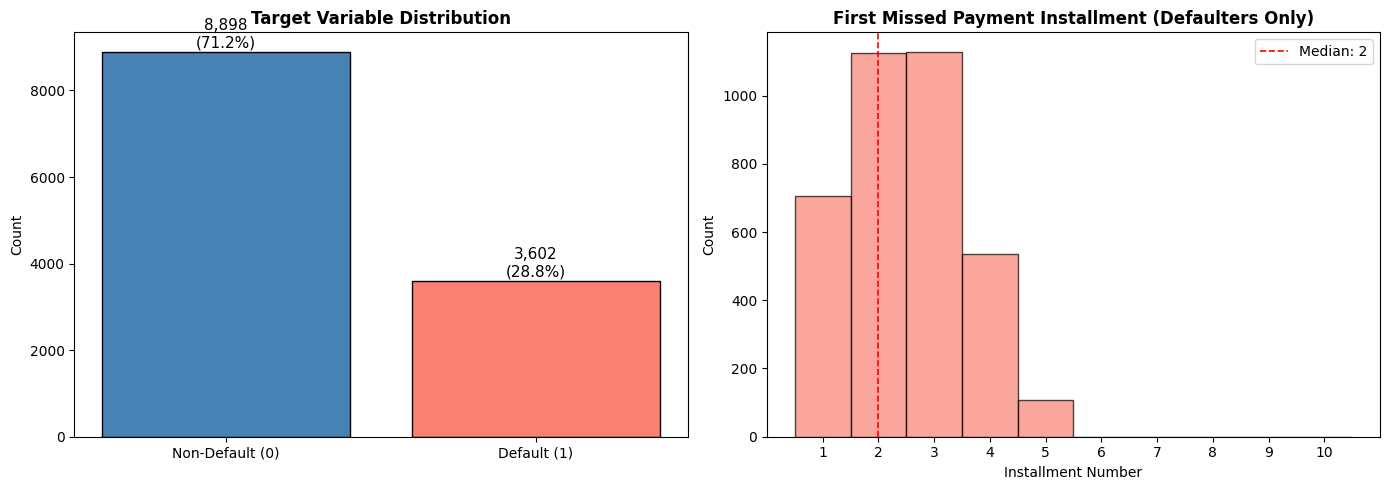

First missed payment distribution (defaulters):
count    3602.0
mean        2.5
std         1.1
min         1.0
25%         2.0
50%         2.0
75%         3.0
max         5.0
Name: installment_num, dtype: float64


In [39]:
# Visualize target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart of default vs non-default
counts = df_target['default'].value_counts()
bars = axes[0].bar(['Non-Default (0)', 'Default (1)'], counts.values,
                   color=['steelblue', 'salmon'], edgecolor='black')
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{count:,}\n({count/len(df_target)*100:.1f}%)',
                 ha='center', fontsize=11)
axes[0].set_title('Target Variable Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

# Right: Histogram of first missed payment installment (defaulters only)
defaulter_ids = df_target[df_target['default'] == 1]['Customer_ID']
df_defaulters = df_loan[df_loan['Customer_ID'].isin(defaulter_ids)]

# Find first installment where paid_amt == 0 and due_amt > 0 (first missed payment)
missed = df_defaulters[(df_defaulters['paid_amt'] == 0) & (df_defaulters['due_amt'] > 0)]
first_miss = missed.groupby('Customer_ID')['installment_num'].min()

axes[1].hist(first_miss, bins=range(1, 12), edgecolor='black', alpha=0.7, color='salmon', align='left')
axes[1].set_title('First Missed Payment Installment (Defaulters Only)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Installment Number')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(1, 11))
median_miss = first_miss.median()
axes[1].axvline(median_miss, color='red', linestyle='--', linewidth=1.2, label=f'Median: {median_miss:.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'First missed payment distribution (defaulters):')
print(first_miss.describe().round(1))

In [38]:
# Show sample defaulters vs non-defaulters payment history
print('=== Sample Defaulter Payment History ===')
sample_def = df_target[df_target['default'] == 1]['Customer_ID'].iloc[0]
print(df_loan[df_loan['Customer_ID'] == sample_def][
    ['installment_num', 'due_amt', 'paid_amt', 'overdue_amt', 'balance']
].to_string(index=False))

print('\n=== Sample Non-Defaulter Payment History ===')
sample_nondef = df_target[df_target['default'] == 0]['Customer_ID'].iloc[0]
print(df_loan[df_loan['Customer_ID'] == sample_nondef][
    ['installment_num', 'due_amt', 'paid_amt', 'overdue_amt', 'balance']
].to_string(index=False))

=== Sample Defaulter Payment History ===
 installment_num  due_amt  paid_amt  overdue_amt  balance
               0      0.0       0.0          0.0  10000.0
               1   1000.0    1000.0          0.0   9000.0
               2   1000.0    1000.0          0.0   8000.0
               3   1000.0       0.0       1000.0   8000.0
               4   1000.0    2000.0          0.0   6000.0
               5   1000.0       0.0       1000.0   6000.0
               6   1000.0       0.0       2000.0   6000.0
               7   1000.0       0.0       3000.0   6000.0
               8   1000.0       0.0       4000.0   6000.0
               9   1000.0       0.0       5000.0   6000.0
              10   1000.0       0.0       6000.0   6000.0

=== Sample Non-Defaulter Payment History ===
 installment_num  due_amt  paid_amt  overdue_amt  balance
               0      0.0       0.0          0.0  10000.0
               1   1000.0    1000.0          0.0   9000.0
               2   1000.0    1000.0        

**Target variable observations:**
- **Definition:** default = 1 if balance > 0 at installment 10 (loan maturity), else 0.
- **Distribution:** 8,898 non-default (71.2%) vs 3,602 default (28.8%). The dataset is imbalanced but not severely. 
- **Data leakage note:** The loan table columns (paid_amt, overdue_amt, balance) beyond installment 0 are future information. They are used only to derive the label, never as features. The feature store must use only data available at the point of loan application.